# Results on 10 images

In [3]:
import numpy as np
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import time
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
device = torch.device("cuda:0")
from torchvision import models

/home/n2/examples/distributed/FSDP2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
images_dir =  'images'
masks_dir = 'masks'

images = {int(item.split(".")[0]):os.path.join(images_dir, item) for item in os.listdir(images_dir)}
masks = {int(item.split(".")[0]):os.path.join(masks_dir, item) for item in os.listdir(masks_dir)}

In [5]:
color_to_index = {
    (61, 61, 245): 0,    
    (184,61,245): 1,     
    (221,255,51): 2,     
    (255,204,51): 3,      
    (255,53,94): 4,
}

In [6]:
class RoadDataset(Dataset):
    def __init__(self, images, masks, color_to_index, transform=None):
        self.images = images
        self.masks = masks
        self.color_to_index = color_to_index  
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        mask_path = self.masks[idx]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")
        mask = np.array(mask)
        mask = self.rgb_to_onehot(mask, self.color_to_index)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask


    def rgb_to_onehot(self, rgb_image, color_map):
        """Converts an RGB image to a one-hot encoded image using a color map."""
        height, width, _ = rgb_image.shape
        num_classes = len(color_map)+1
        onehot_image = np.zeros((height, width, num_classes), dtype=np.float32)
        for h in range(height):
            for w in range(width):
                rgb = tuple(rgb_image[h, w])
                if rgb in color_map:
                    class_index = color_map[rgb]
                    onehot_image[h, w, class_index] = 1.0
                else:
                    onehot_image[h, w, 5] = 1.0 
        return onehot_image

In [17]:
transform = transforms.Compose([transforms.ToTensor()])
batch_size = 2

image_train_paths, image_test_paths, mask_train_paths, mask_test_paths = train_test_split(
    images, masks, test_size=0.3, random_state=42
)
train_dataset = RoadDataset(image_train_paths, mask_train_paths, color_to_index=color_to_index, transform=transform)
test_dataset = RoadDataset(image_test_paths, mask_test_paths, color_to_index=color_to_index, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [21]:
class FCN(nn.Module):
    def __init__(self, num_classes=6):
        super(FCN, self).__init__()

        # Encoder
        self.conv1_1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3_1 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, 3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.conv4_1 = nn.Conv2d(256, 512, 3, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.conv5_1 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, 3, padding=1)
        self.pool5 = nn.MaxPool2d(2, 2)

        # Classifier
        self.fc6 = nn.Conv2d(512, 4096, 7)
        self.fc7 = nn.Conv2d(4096, 4096, 1)

        self.drop6 = nn.Dropout2d(0.5)
        self.drop7 = nn.Dropout2d(0.5)

        self.score_fr = nn.Conv2d(4096, num_classes, 1)
        self.score_pool4 = nn.Conv2d(512, num_classes, 1)
        self.score_pool3 = nn.Conv2d(256, num_classes, 1)

    def forward(self, x):
        inp = x

        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)

        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = F.relu(self.conv3_3(x))
        pool3 = self.pool3(x)

        x = F.relu(self.conv4_1(pool3))
        x = F.relu(self.conv4_2(x))
        x = F.relu(self.conv4_3(x))
        pool4 = self.pool4(x)

        x = F.relu(self.conv5_1(pool4))
        x = F.relu(self.conv5_2(x))
        x = F.relu(self.conv5_3(x))
        x = self.pool5(x)

        x = F.relu(self.fc6(x))
        x = self.drop6(x)

        x = F.relu(self.fc7(x))
        x = self.drop7(x)

        score = self.score_fr(x)

        up2 = F.interpolate(score, size=pool4.shape[2:], mode="bilinear", align_corners=False)
        fuse4 = up2 + self.score_pool4(pool4)

        up_pool4 = F.interpolate(fuse4, size=pool3.shape[2:], mode="bilinear", align_corners=False)
        fuse3 = up_pool4 + self.score_pool3(pool3)

        out = F.interpolate(fuse3, size=inp.shape[2:], mode="bilinear", align_corners=False)

        return out

In [22]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        self.ds_conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.ds_bn1 = nn.BatchNorm2d(16)
        self.ds_pool1 = nn.MaxPool2d(2, stride=2)

        self.ds_conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.ds_bn2 = nn.BatchNorm2d(32)
        self.ds_pool2 = nn.MaxPool2d(2, stride=2)

        self.bottleneck_conv = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bottleneck_bn = nn.BatchNorm2d(64)

        self.us_upsample1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.us_conv1 = nn.Conv2d(64 + 32, 32, kernel_size=3, padding=1) 
        self.us_bn1 = nn.BatchNorm2d(32)

        self.us_upsample2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.us_conv2 = nn.Conv2d(32 + 16, 16, kernel_size=3, padding=1) 
        self.us_bn2 = nn.BatchNorm2d(16)

        self.final_conv = nn.Conv2d(16, 6, kernel_size=1) 

    def forward(self, x):
        down1 = F.leaky_relu(self.ds_bn1(self.ds_conv1(x)))
        x = self.ds_pool1(down1)

        down2 = F.leaky_relu(self.ds_bn2(self.ds_conv2(x)))
        x = self.ds_pool2(down2)

        x = F.leaky_relu(self.bottleneck_bn(self.bottleneck_conv(x)))

        x = self.us_upsample1(x)
        x = torch.cat([x, down2], dim=1) 
        x = F.leaky_relu(self.us_bn1(self.us_conv1(x)))

        x = self.us_upsample2(x)
        x = torch.cat([x, down1], dim=1)
        x = F.leaky_relu(self.us_bn2(self.us_conv2(x)))

        x = self.final_conv(x) 
        return x

In [23]:
unet, fcn = UNet().to(device), FCN().to(device)
unet.load_state_dict(torch.load("unet_latest.pt", weights_only=True))
fcn.load_state_dict(torch.load("fcn_latest.pt", weights_only=True))

<All keys matched successfully>

In [31]:
def display_tensor_image(unet_out, fcn_out, mask):
    tensors = [unet_out, fcn_out, mask]

    processed = []
    for t in tensors:
        if t.ndim == 3 and t.shape[0] == 3:
            t = t.permute(1, 2, 0)
        processed.append(t.cpu().numpy().astype(np.uint8))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    titles = ["UNet mask", "FCN mask", "Ground truth"]

    for ax, img, title in zip(axes, processed, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [27]:
def index_to_rgb(outputs, color_map, reference_images):
    if not isinstance(outputs, torch.Tensor):
        return None
    if not isinstance(color_map, dict):
        return None
    if not isinstance(reference_images, torch.Tensor):
        return None
    if len(outputs.shape) != 4:
        return None

    batch_size, _, h, w = outputs.shape

    if reference_images.shape != (batch_size, 3, h, w):
        return None

    rgb_images = torch.zeros((batch_size, 3, h, w), dtype=torch.uint8, device=outputs.device)
    reference_images = (reference_images * 255).clamp(0, 255).to(torch.uint8)
    predicted_indices = torch.argmax(outputs, dim=1)
    for b in range(batch_size):
        masks = torch.zeros((h, w), dtype=torch.bool, device=outputs.device)

        for color, index in color_map.items():
            mask = predicted_indices[b] == index
            masks |= mask

            rgb_images[b, :, mask] = torch.tensor(
                color, dtype=torch.uint8, device=outputs.device
            ).view(3, 1)

        rgb_images[b] = torch.where(
            masks.unsqueeze(0),
            rgb_images[b],
            reference_images[b]
        )

    return rgb_images

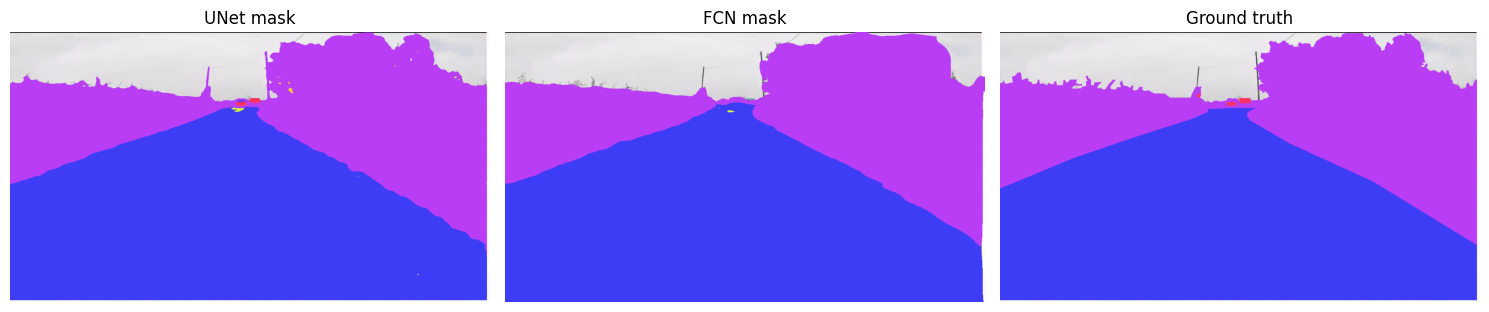

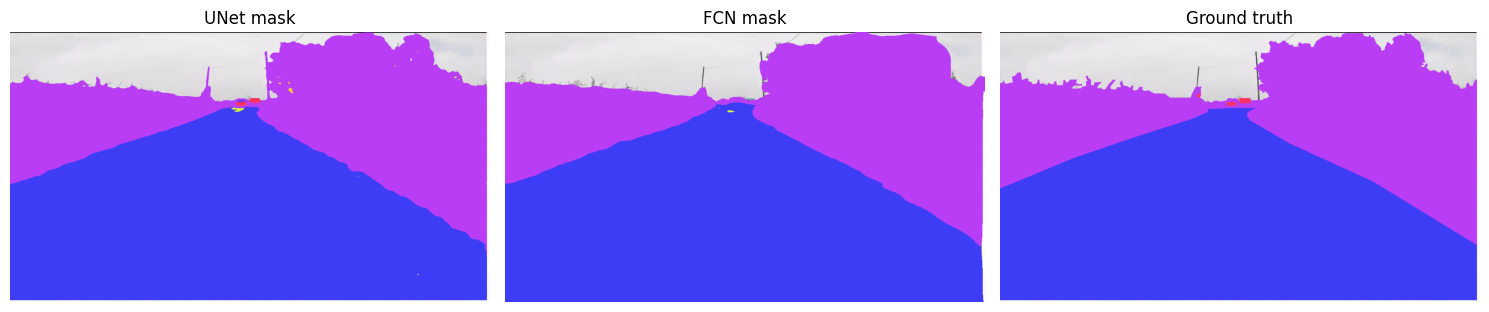

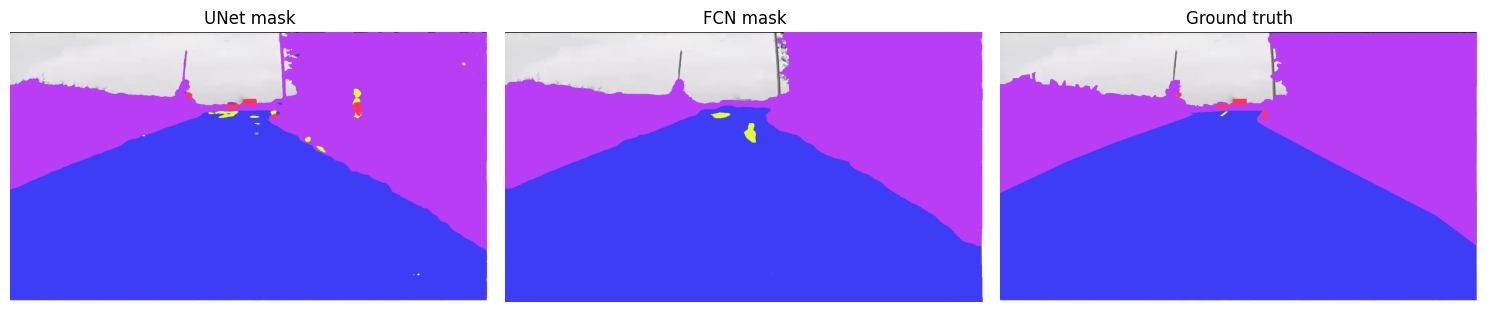

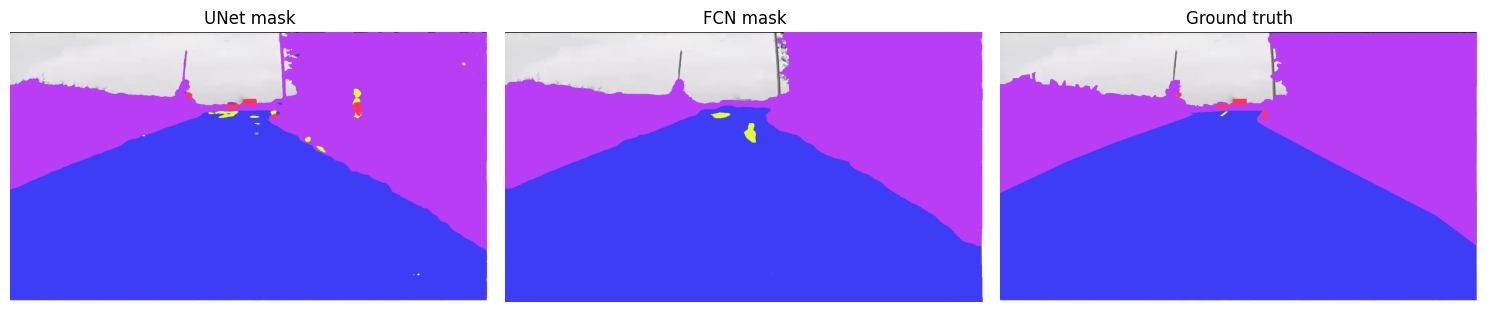

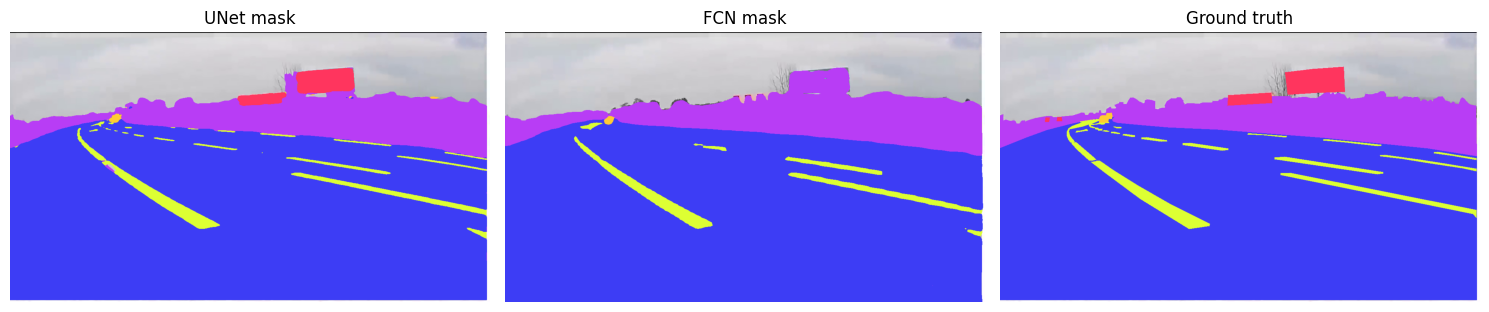

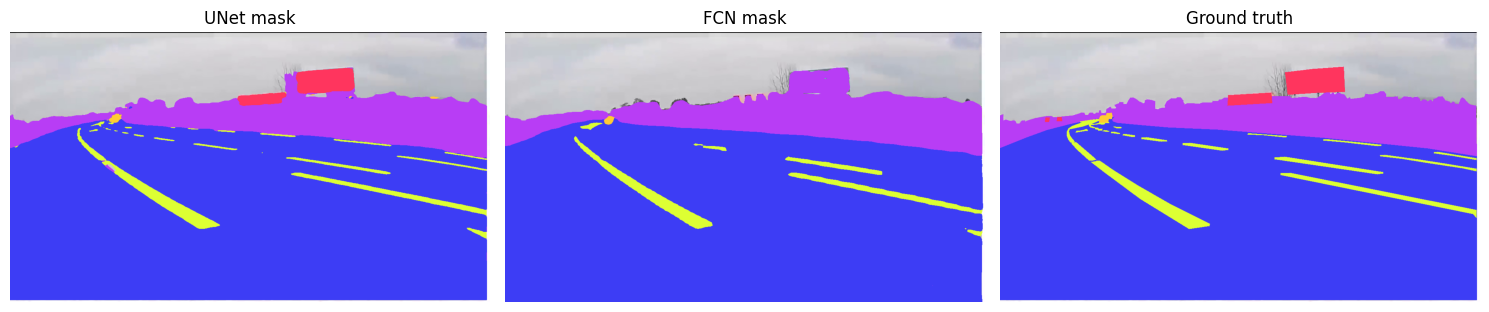

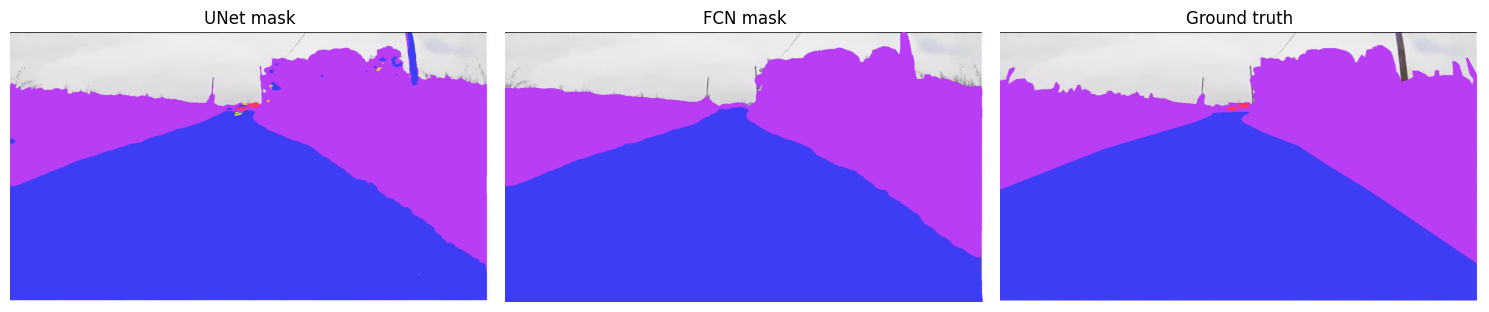

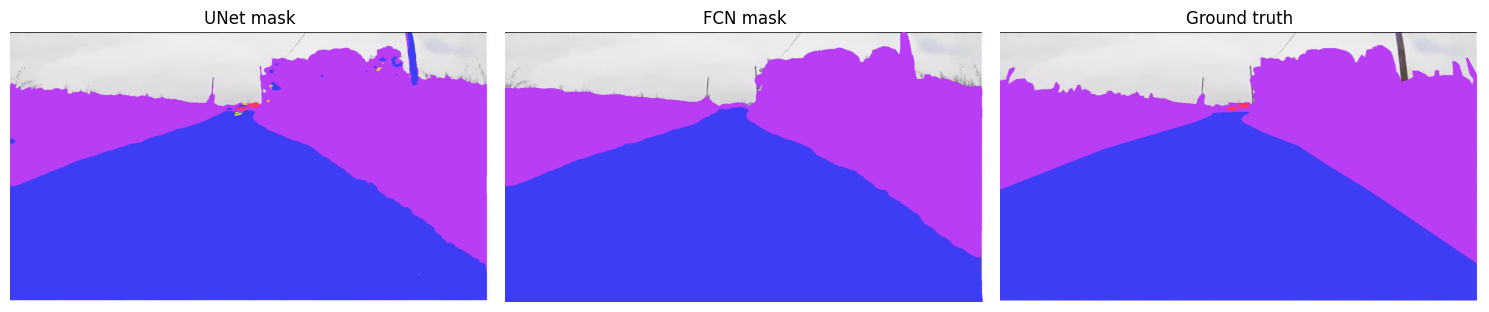

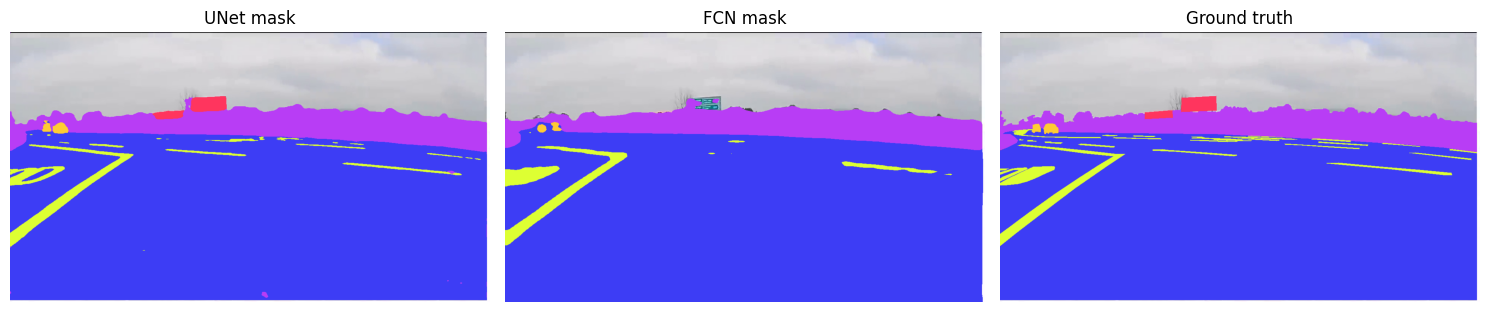

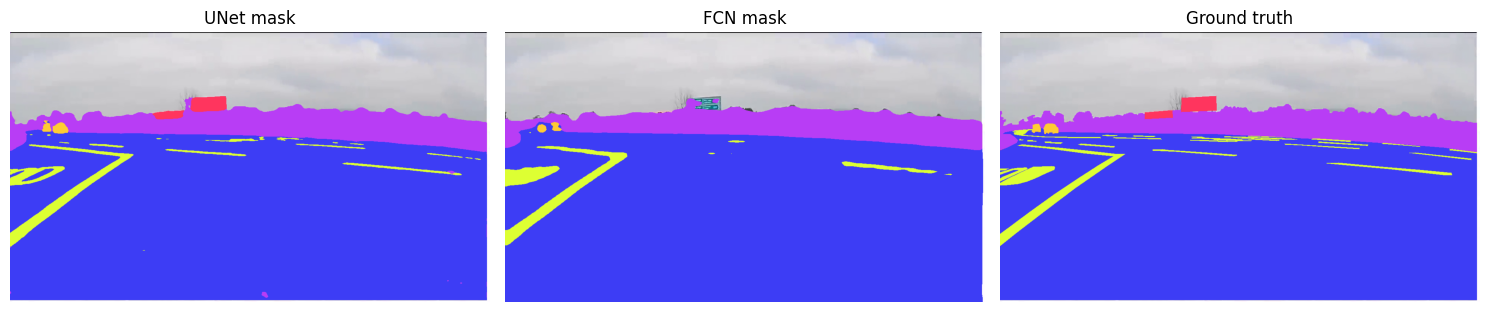

In [32]:
with torch.no_grad():
    n_test_steps = len(test_loader)
    epoch_loss = 0
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        outputs_unet = unet(images).detach().cpu()
        outputs_fcn = fcn(images).detach().cpu()
        predicted_rgb_unet = index_to_rgb(outputs_unet, color_to_index, images.detach().cpu())
        predicted_rgb_fcn = index_to_rgb(outputs_fcn, color_to_index, images.detach().cpu())
        predicted_masks = index_to_rgb(labels.detach().cpu(), color_to_index, images.detach().cpu())
        display_tensor_image(unet_out=predicted_rgb_unet[0], fcn_out=predicted_rgb_fcn[0], mask=predicted_masks[0])
        display_tensor_image(unet_out=predicted_rgb_unet[0], fcn_out=predicted_rgb_fcn[0], mask=predicted_masks[0])
           


# Results explanation

### Unet has proven to be a lot more stable to train and converges to a lower overall validation loss (± 0.12 Dice loss), when compared to the FCN loss (± 0.26). Furthermore, UNet tends to converge to a similar loss predictibely no matter the random inintialization. With FCN, I have found the results to be harder to reproduce without conrolling for random seed, which suggests high susceptibility to initialization parameters.
#### This can be explained by the maturity of UNet and its utilization of skip connections, in addition to UNet being the newer of the two architectures, which traditionally indicates enhancements on previous literature (including FCN). FCN seems to fail at capturing smaller classes like road signs, those might be harder to learn due to the small amount of pixels covering them hence making the gradients less powerful, which unet solves by its skip connections.